# CP1 - EDA и подготовка данных

**Задача:** Регрессия — предсказание концентрации PM2.5 (мкг/м³) в атмосфере Пекина.  
**Датасет:** Beijing Multi-Site Air-Quality Data (UCI / Kaggle)  
**Источник:** https://www.kaggle.com/datasets/sid321axn/beijing-multisite-airquality-data-set  

**Почему выбран датасет:**  
- Более 420 000 строк, 12 станций мониторинга, период 2013–2017.  
- Реальная экологическая задача с практическим значением.  
- Богатый набор фич: химические показатели + метеорология + временные паттерны.

**Метрика качества:** RMSE (Root Mean Squared Error)  
- Штрафует большие ошибки сильнее, что важно для задачи: ошибочное предсказание чистого воздуха при высоком PM2.5 опасно для здоровья.  
- Дополнительно смотрим MAE (интерпретируемость) и R² (доля объяснённой дисперсии).

**Структура ноутбука:**  
1. Загрузка и первичный осмотр данных  
2. Анализ пропусков  
3. Анализ выбросов  
4. Распределения признаков  
5. Корреляционный анализ  
6. Временные паттерны  
7. Обработка данных  
8. Feature Engineering  
9. Сплит train / val / test  
10. Сохранение обработанных данных

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    load_raw_data, make_datetime, remove_duplicates,
    handle_missing_values, remove_outliers_iqr,
    encode_wind_direction, encode_station,
    add_time_features, add_lag_features, add_rolling_features,
    time_based_split, WIND_DIR_MAP,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 1. Загрузка данных

In [2]:
df_raw = load_raw_data(RAW_DIR)
print(f"Строк: {len(df_raw):,}  |  Колонок: {df_raw.shape[1]}")
df_raw.head()

Строк: 420,768  |  Колонок: 18


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [3]:
print("Типы данных:")
print(df_raw.dtypes)
print("\nСтанции:", df_raw["station"].unique())
print(f"Период: {df_raw['year'].min()} – {df_raw['year'].max()}")

Типы данных:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object

Станции: <ArrowStringArray>
[ 'Aotizhongxin',     'Changping',      'Dingling',        'Dongsi',
      'Guanyuan',       'Gucheng',       'Huairou',  'Nongzhanguan',
        'Shunyi',       'Tiantan',        'Wanliu', 'Wanshouxigong']
Length: 12, dtype: str
Период: 2013 – 2017


In [4]:
df_raw.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


## 2. Анализ пропусков

       count   pct
CO     20701  4.92
O3     13277  3.16
NO2    12116  2.88
SO2     9021  2.14
PM2.5   8739  2.08
PM10    6449  1.53
wd      1822  0.43
DEWP     403  0.10
TEMP     398  0.09
PRES     393  0.09
RAIN     390  0.09
WSPM     318  0.08


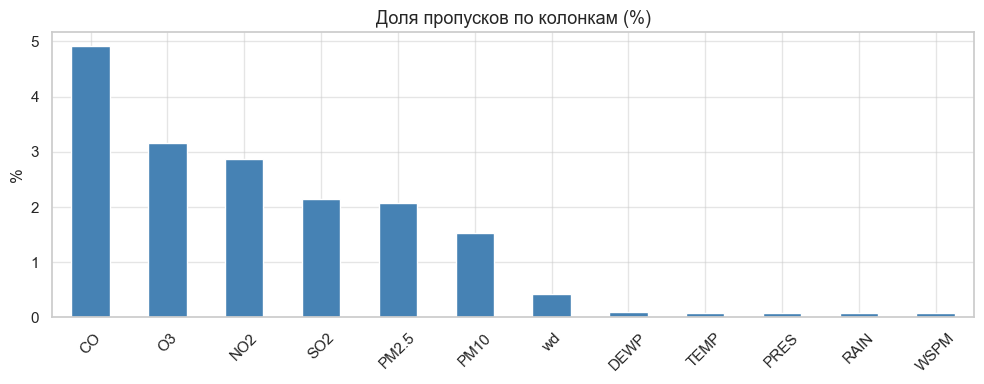

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("pct", ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
missing_df["pct"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Доля пропусков по колонкам (%)", fontsize=13)
ax.set_ylabel("%")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "missing_values.png"), dpi=100)
plt.show()

**Вывод:** PM2.5 и другие концентрации загрязнителей имеют пропуски ~2-5%. Стратегия - forward-fill по станции (данные временные, значение предыдущего часа близко к текущему), затем median fill для оставшихся.

## 3. Анализ распределения целевой переменной

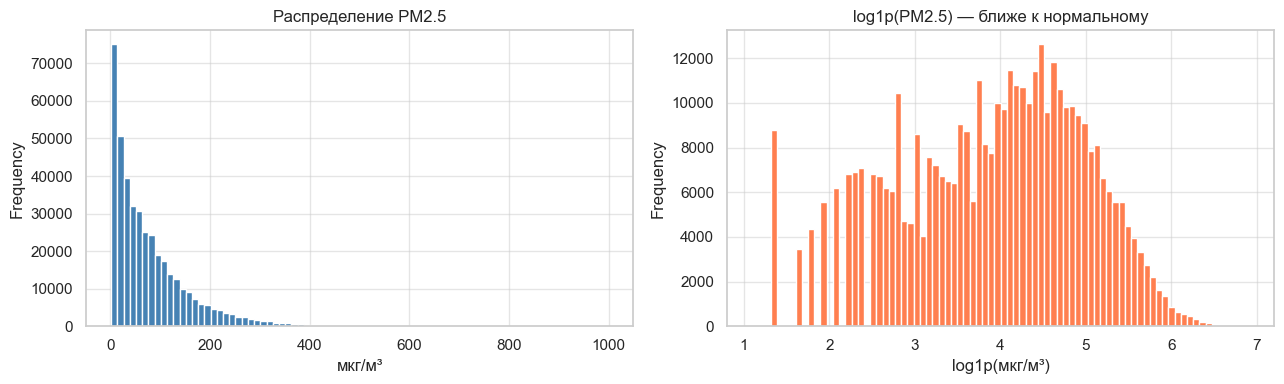

PM2.5 — медиана: 55.0, среднее: 79.8, макс: 999.0


In [6]:
os.makedirs(os.path.join(PROJECT_ROOT, "report", "images"), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_raw["PM2.5"].dropna().plot(
    kind="hist", bins=80, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Распределение PM2.5")
axes[0].set_xlabel("мкг/м³")

np.log1p(df_raw["PM2.5"].dropna()).plot(
    kind="hist", bins=80, ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("log1p(PM2.5) — ближе к нормальному")
axes[1].set_xlabel("log1p(мкг/м³)")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "pm25_distribution.png"), dpi=100)
plt.show()

print(f"PM2.5 — медиана: {df_raw['PM2.5'].median():.1f}, среднее: {df_raw['PM2.5'].mean():.1f}, макс: {df_raw['PM2.5'].max():.1f}")

**Вывод:** Распределение правостороннее (long tail). Максимальные значения PM2.5 > 700 мкг/м³ — явные выбросы (норма ВОЗ — 25 мкг/м³ в сутки). Будем удалять экстремальные выбросы по методу 3*IQR.

## 4. Анализ выбросов по всем числовым признакам

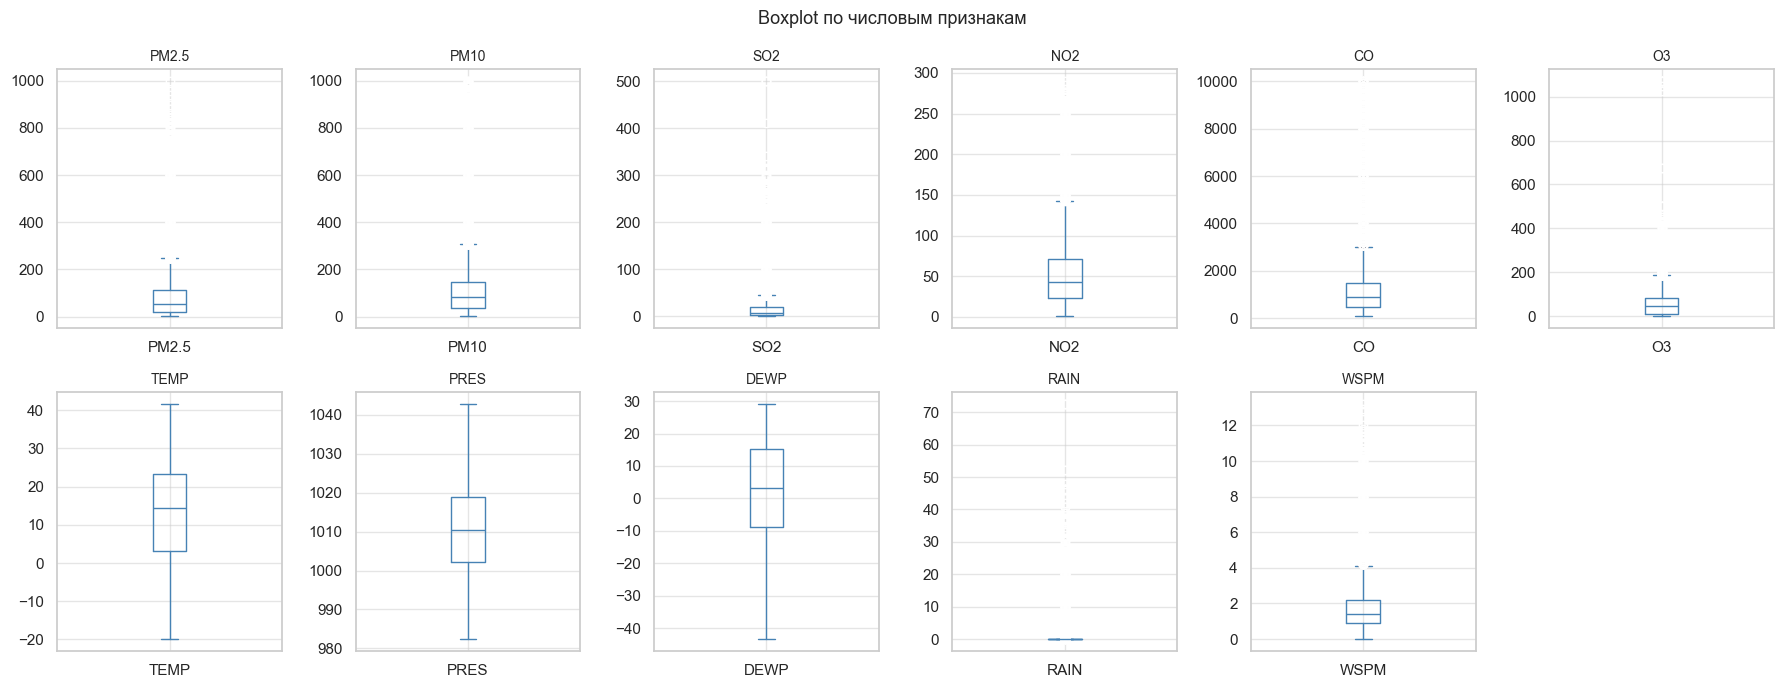

In [7]:
num_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df_raw[col].dropna().plot(kind="box", ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=10)

axes[-1].set_visible(False)
plt.suptitle("Boxplot по числовым признакам", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "boxplots.png"), dpi=100)
plt.show()

## 5. Корреляционный анализ

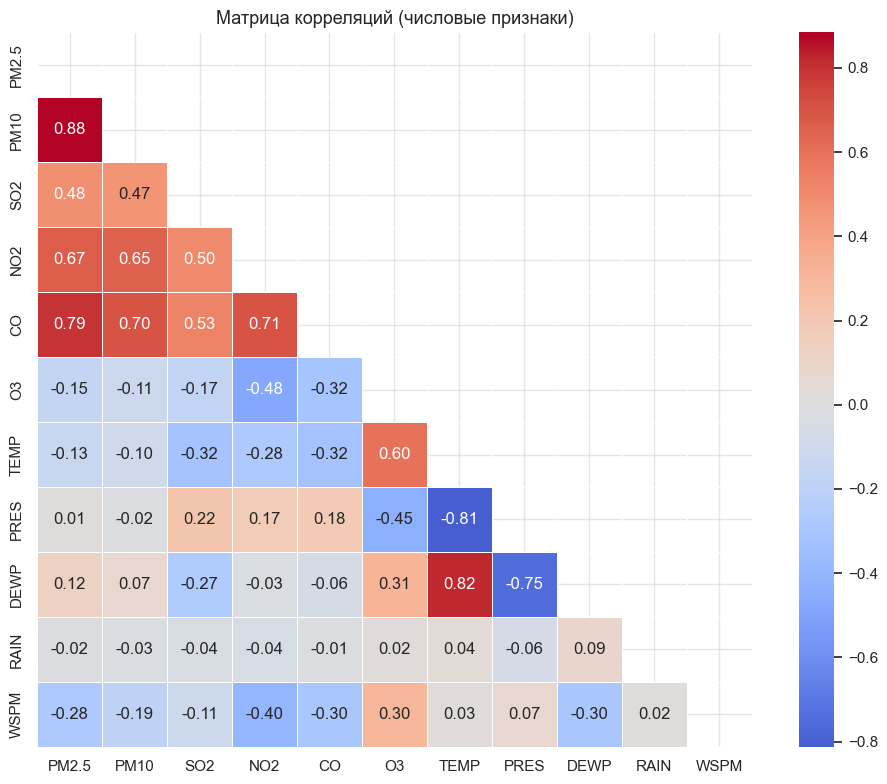

Корреляция с PM2.5:
PM2.5    1.000000
PM10     0.884605
CO       0.792170
NO2      0.670681
SO2      0.481735
DEWP     0.117214
PRES     0.014295
RAIN    -0.015347
TEMP    -0.129697
O3      -0.151580
WSPM    -0.275844
Name: PM2.5, dtype: float64


In [8]:
corr_df = df_raw[num_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax, square=True, linewidths=0.5
)
ax.set_title("Матрица корреляций (числовые признаки)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "correlation_heatmap.png"), dpi=100)
plt.show()

print("Корреляция с PM2.5:")
print(corr_matrix["PM2.5"].sort_values(ascending=False))

## 6. Временные паттерны

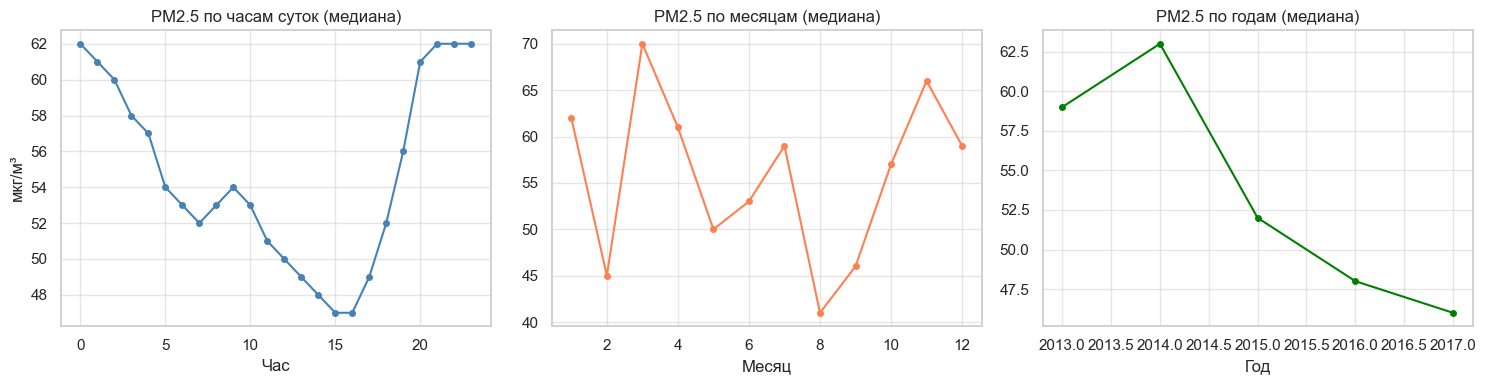

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# По часам суток
hourly = df_raw.groupby("hour")["PM2.5"].median()
hourly.plot(ax=axes[0], color="steelblue", marker="o", markersize=4)
axes[0].set_title("PM2.5 по часам суток (медиана)")
axes[0].set_xlabel("Час")
axes[0].set_ylabel("мкг/м³")

# По месяцам
monthly = df_raw.groupby("month")["PM2.5"].median()
monthly.plot(ax=axes[1], color="coral", marker="o", markersize=4)
axes[1].set_title("PM2.5 по месяцам (медиана)")
axes[1].set_xlabel("Месяц")

# По годам
yearly = df_raw.groupby("year")["PM2.5"].median()
yearly.plot(ax=axes[2], color="green", marker="o", markersize=4)
axes[2].set_title("PM2.5 по годам (медиана)")
axes[2].set_xlabel("Год")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "time_patterns.png"), dpi=100)
plt.show()

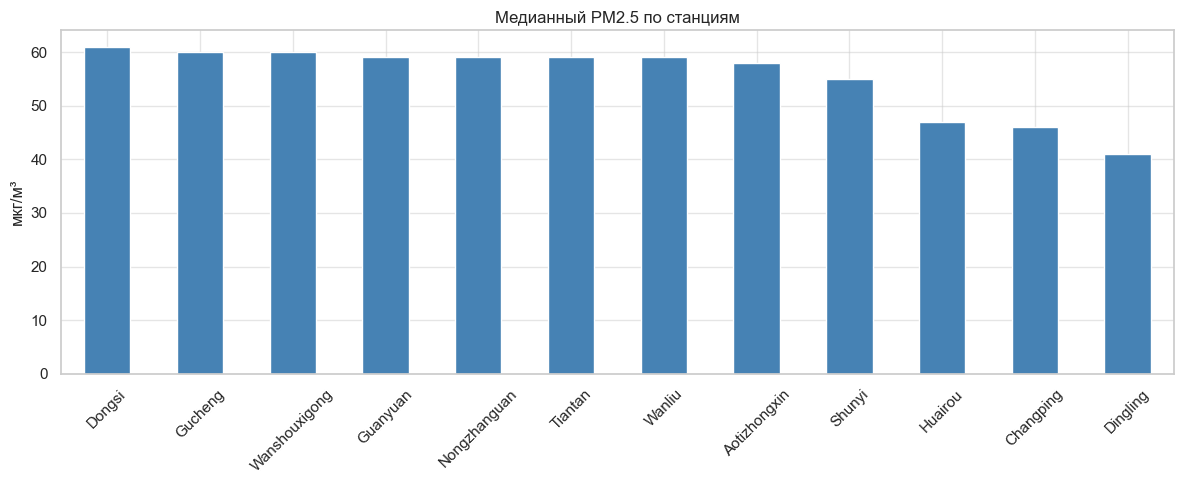

In [10]:
# PM2.5 по станциям
fig, ax = plt.subplots(figsize=(12, 5))
station_median = df_raw.groupby("station")["PM2.5"].median().sort_values(ascending=False)
station_median.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Медианный PM2.5 по станциям")
ax.set_ylabel("мкг/м³")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "pm25_by_station.png"), dpi=100)
plt.show()

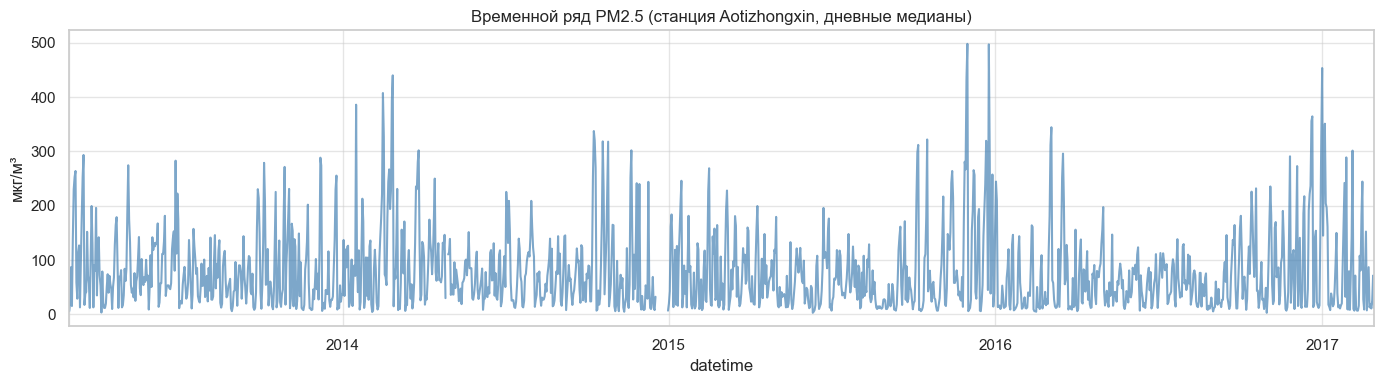

In [11]:
station_ex = df_raw["station"].value_counts().index[0]
ts = df_raw[df_raw["station"] == station_ex].copy()
ts = make_datetime(ts).set_index("datetime")["PM2.5"].resample("D").median()

fig, ax = plt.subplots(figsize=(14, 4))
ts.plot(ax=ax, alpha=0.7, color="steelblue")
ax.set_title(f"Временной ряд PM2.5 (станция {station_ex}, дневные медианы)")
ax.set_ylabel("мкг/м³")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "timeseries.png"), dpi=100)
plt.show()

## 7. Обработка данных

In [12]:
df = load_raw_data(RAW_DIR)

df = make_datetime(df)
print(f"После make_datetime: {len(df):,} строк")

df = remove_duplicates(df)
print(f"После remove_duplicates: {len(df):,} строк")

df = handle_missing_values(df)
print(f"После handle_missing_values: {len(df):,} строк")
print(f"Оставшиеся пропуски: {df.isnull().sum().sum()}")

df = remove_outliers_iqr(df, target_col="PM2.5")
print(f"После remove_outliers_iqr: {len(df):,} строк")

После make_datetime: 420,768 строк
После remove_duplicates: 420,768 строк
После handle_missing_values: 420,768 строк
Оставшиеся пропуски: 0
Removed 3488 outlier rows from 'PM2.5'.
После remove_outliers_iqr: 417,280 строк


## 8. Feature Engineering

Признаки, которые добавляем:

| Признак | Описание | Мотивация |
|---|---|---|
| `hour_sin`, `hour_cos` | Циклическое кодирование часа | Час 23 и 0 близки |
| `month_sin`, `month_cos` | Циклическое кодирование месяца | Сезонность |
| `day_of_week`, `is_weekend` | День недели | Трафик / промышленность |
| `wd_sin`, `wd_cos` | Направление ветра как вектор | Непрерывное кодирование угла |
| `station_enc` | Числовой код станции | Разные районы города |
| `PM2.5_lag1/2/3/24` | Лаги цели | Авторегрессия: воздух инерционен |
| `PM2.5_roll3`, `PM2.5_roll24` | Скользящее среднее | Тренд за последние 3/24 часа |

In [13]:
df = encode_wind_direction(df)
df = encode_station(df)
df = add_time_features(df)
df = add_lag_features(df, target_col="PM2.5", lags=[1, 2, 3, 24])
df = add_rolling_features(df, target_col="PM2.5", windows=[3, 24])

print(f"Итоговое число признаков: {df.shape[1]}")
print(f"Строк: {len(df):,}")
df.head(3)

Итоговое число признаков: 33
Строк: 416,992


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,month_sin,month_cos,day_of_week,is_weekend,PM2.5_lag1,PM2.5_lag2,PM2.5_lag3,PM2.5_lag24,PM2.5_roll3,PM2.5_roll24
0,25,2013,3,2,0,22.0,24.0,24.0,44.0,500.0,...,1.0,6.123234e-17,5,1,24.0,15.0,12.0,4.0,NaN,NaN
1,26,2013,3,2,1,14.0,17.0,21.0,36.0,400.0,...,1.0,6.123234e-17,5,1,22.0,24.0,15.0,8.0,22.0,22.0
2,27,2013,3,2,2,13.0,13.0,20.0,37.0,400.0,...,1.0,6.123234e-17,5,1,14.0,22.0,24.0,7.0,18.0,18.0


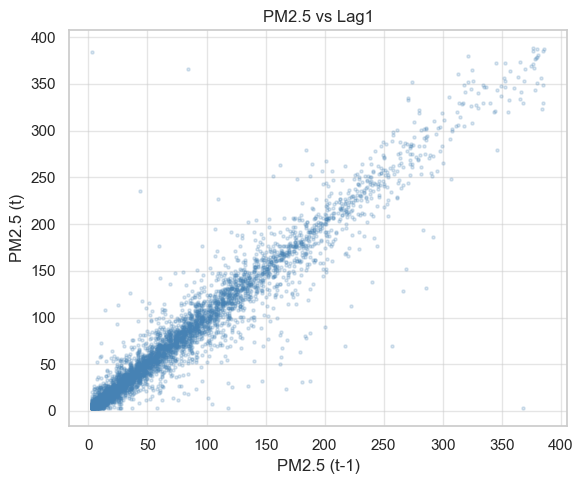

In [14]:
sample = df.sample(5000, random_state=RANDOM_SEED)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample["PM2.5_lag1"], sample["PM2.5"], alpha=0.2, s=5, color="steelblue")
ax.set_xlabel("PM2.5 (t-1)")
ax.set_ylabel("PM2.5 (t)")
ax.set_title("PM2.5 vs Lag1")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "report", "images", "lag1_scatter.png"), dpi=100)
plt.show()

## 9. Train / Val / Test сплит

**Стратегия:** сплит по времени, а не случайный.  
**Почему:** данные временные (time series). Случайный сплит привёл бы к data leakage - модель видела бы будущие значения при обучении (лаги и скользящие средние), что нереалистично.

Разбиение:
- **Train:** 2013–2015 (3 года, большинство данных)
- **Val:** 2016 (для подбора гиперпараметров)
- **Test:** 2017 (финальная оценка, не трогаем до конца)

In [15]:
train, val, test = time_based_split(df, val_year=2016, test_year=2017)

print(f"Train: {len(train):,} строк  ({train['year'].min()}–{train['year'].max()})")
print(f"Val:   {len(val):,} строк  ({val['year'].min()}–{val['year'].max()})")
print(f"Test:  {len(test):,} строк  ({test['year'].min()}–{test['year'].max()})")

total = len(train) + len(val) + len(test)
print(f"\nДоли: train {len(train)/total:.1%} / val {len(val)/total:.1%} / test {len(test)/total:.1%}")

Train: 295,871 строк  (2013–2015)
Val:   104,617 строк  (2016–2016)
Test:  16,504 строк  (2017–2017)

Доли: train 71.0% / val 25.1% / test 4.0%


In [16]:
assert train["datetime"].max() < val["datetime"].min(), "Leak: train/val пересекаются!"
assert val["datetime"].max() < test["datetime"].min(), "Leak: val/test пересекаются!"
print("Проверка на data leakage: OK")

Проверка на data leakage: OK


## 10. Сохранение обработанных данных

In [17]:
os.makedirs(PROCESSED_DIR, exist_ok=True)

train.to_parquet(os.path.join(PROCESSED_DIR, "train.parquet"), index=False)
val.to_parquet(os.path.join(PROCESSED_DIR, "val.parquet"), index=False)
test.to_parquet(os.path.join(PROCESSED_DIR, "test.parquet"), index=False)

print("Сохранено:")
for split, ds in [("train", train), ("val", val), ("test", test)]:
    path = os.path.join(PROCESSED_DIR, f"{split}.parquet")
    size_mb = os.path.getsize(path) / 1024**2
    print(f"  {split}.parquet — {len(ds):,} строк, {size_mb:.1f} MB")

Сохранено:
  train.parquet — 295,871 строк, 7.2 MB
  val.parquet — 104,617 строк, 2.4 MB
  test.parquet — 16,504 строк, 0.4 MB


## Итоги EDA

- **Пропуски:** ~2-5% в химических показателях, заполнены forward-fill по станции + median fallback.
- **Выбросы:** удалены экстремальные значения PM2.5 (> Q3 + 3*IQR) — около 1% данных.  
- **Самые коррелированные с PM2.5:** PM10, CO, NO2 (r > 0.7). O3 — отрицательная корреляция (фотохимическая реакция).  
- **Временные паттерны:** пик PM2.5 зимой (отопление), пиковые часы — утро и вечер (трафик).  
- **Feature engineering:** добавлены лаги 1/2/3/24 часа и скользящие средние 3/24 часа — PM2.5 сильно авторегрессивный.  
- **Сплит:** по времени, train 2013–2015 / val 2016 / test 2017. Data leakage исключён.